In [95]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [97]:
from google.colab import files
uploaded = files.upload()


Saving 1730285881-Airbnb_Open_Data.xlsx to 1730285881-Airbnb_Open_Data (2).xlsx


In [99]:
import pandas as pd

df = pd.read_excel("1730285881-Airbnb_Open_Data (2).xlsx")
print(df.head())


        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee  minimum nights  \
0  40.64749 -73.97237  United S

2. Data Cleaning
# Check for missing values

In [100]:
print("\n===== Missing Values =====")
print(df.isnull().sum())


===== Missing Values =====
id                                     0
NAME                                 270
host id                                0
host_identity_verified               289
host name                            408
neighbourhood group                   29
neighbourhood                         16
lat                                    8
long                                   8
country                              532
country code                         131
instant_bookable                     105
cancellation_policy                   76
room type                              0
Construction year                    214
price                                247
service fee                          273
minimum nights                       409
number of reviews                    183
last review                        15893
reviews per month                  15879
review rate number                   326
calculated host listings count       319
availability 365             

# Drop duplicates

In [101]:
df = df.drop_duplicates()


# Fill missing numeric values with median

In [102]:
df = df.fillna(df.median(numeric_only=True))

# Fill missing categorical values with mode

In [103]:
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].fillna(df[col].mode()[0])



3. Exploratory Data Analysis
# ===============================

# --- Price distribution ---

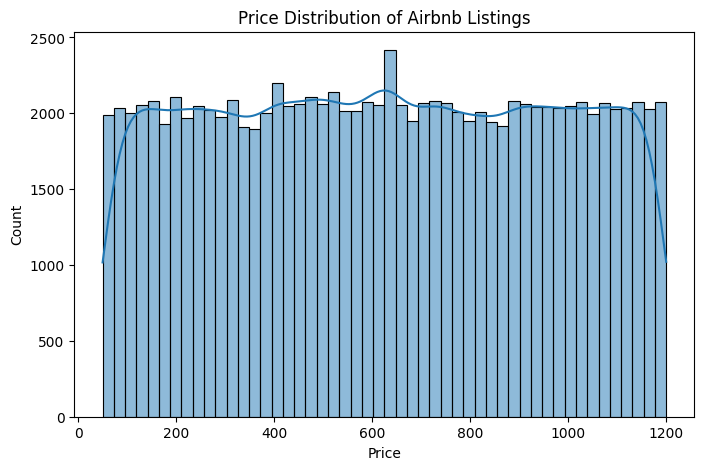

In [104]:
if "price" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["price"], bins=50, kde=True)
    plt.title("Price Distribution of Airbnb Listings")
    plt.xlabel("Price")
    plt.ylabel("Count")
    plt.show()

# --- Average price by neighbourhood ---

/tmp/ipython-input-1442637878.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_price.values, y=avg_price.index, palette="viridis")


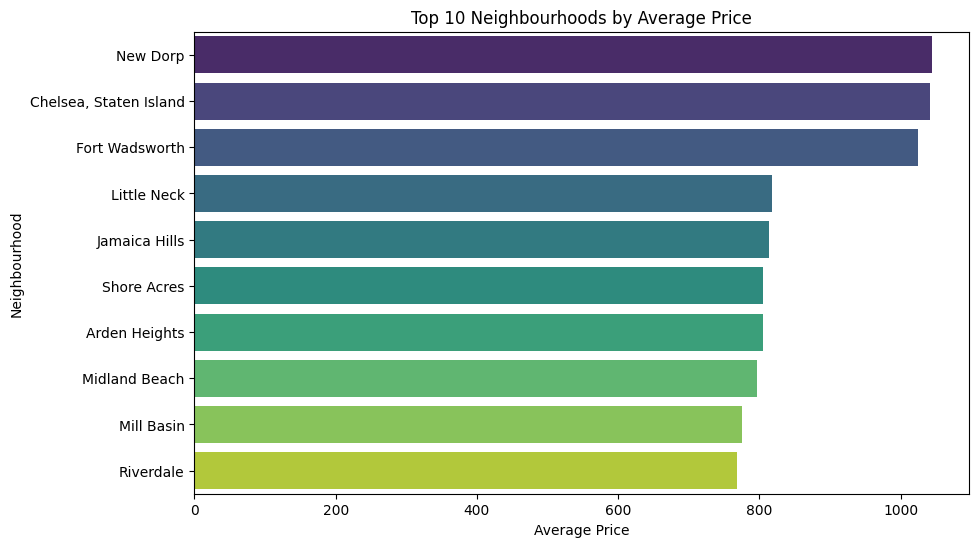

In [105]:
if "neighbourhood" in df.columns:
    plt.figure(figsize=(10,6))
    avg_price = df.groupby("neighbourhood")["price"].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=avg_price.values, y=avg_price.index, palette="viridis")
    plt.title("Top 10 Neighbourhoods by Average Price")
    plt.xlabel("Average Price")
    plt.ylabel("Neighbourhood")
    plt.show()

# --- Room type distribution ---

/tmp/ipython-input-2387733192.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="room type", order=df["room type"].value_counts().index, palette="Set2")


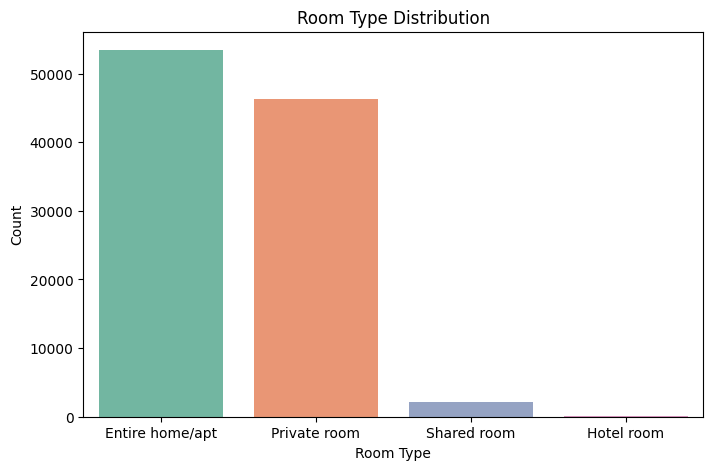

In [106]:
# --- Room type distribution ---
if "room type" in df.columns:
    plt.figure(figsize=(8,5))
    sns.countplot(data=df, x="room type", order=df["room type"].value_counts().index, palette="Set2")
    plt.title("Room Type Distribution")
    plt.xlabel("Room Type")
    plt.ylabel("Count")
    plt.show()
else:
    print("⚠️ 'room type' column not found in dataset.")





# --- Availability analysis ---

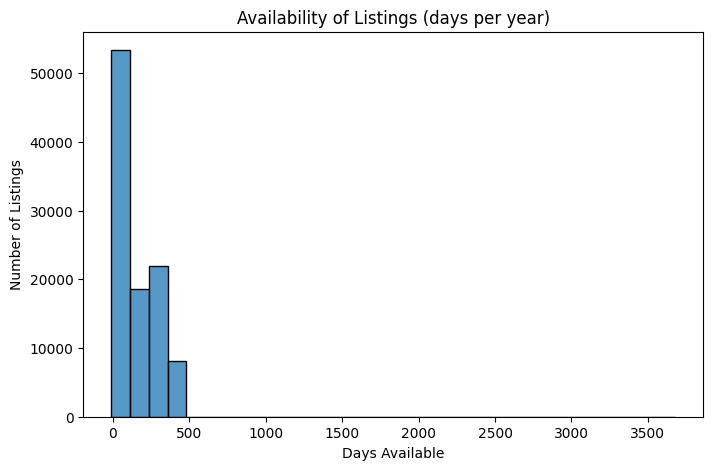

In [110]:
if "availability 365" in df.columns:
    plt.figure(figsize=(8,5))
    sns.histplot(df["availability 365"], bins=30, kde=False)
    plt.title("Availability of Listings (days per year)")
    plt.xlabel("Days Available")
    plt.ylabel("Number of Listings")
    plt.show()

Save Cleaned Dataset


In [111]:
cleaned_file = "/content/Airbnb_Cleaned.csv"
df.to_csv(cleaned_file, index=False)
print(f"Cleaned dataset saved as: {cleaned_file}")

Cleaned dataset saved as: /content/Airbnb_Cleaned.csv
